<a href="https://colab.research.google.com/github/jaumg2004/Academia-Digital/blob/main/lab/c24_2026_1_ll_atividade_07_mmmm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 07: MLP e CNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_07_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [ ]:
!pip install tensorflow numpy matplotlib seaborn scikit-learn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [ ]:
# Carregando o dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Ajustando dimensões dos rótulos
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Separando validação do treino
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Classes do dataset
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

### <font color='#2D9CDB'>Q1) O dataset CIFAR-10 é amplamente utilizado em problemas de visão computacional e classificação de imagens. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o tipo de imagens que ela contém, a quantidade de classes existentes e alguns exemplos de objetos presentes nas imagens.</font>

O CIFAR-10, sigla para *Canadian Institute for Advanced Research*, é um conjunto de dados muito utilizado em tarefas de visão computacional, principalmente em problemas de classificação de imagens. Ele foi criado para servir como uma base padronizada de avaliação de modelos de aprendizado de máquina e redes neurais. O dataset contém imagens coloridas de baixa resolução, com dimensão de 32×32 pixels, organizadas em 10 classes diferentes: avião, automóvel, pássaro, gato, cervo, cachorro, sapo, cavalo, navio e caminhão. Ao todo, são 60.000 imagens, sendo 50.000 para treinamento e 10.000 para teste, com 6.000 imagens por classe. Por conter objetos reais, variações de fundo, iluminação e posição, o CIFAR-10 é uma base simples em tamanho, mas desafiadora para classificação automática.

### <font color='#2D9CDB'>Q2) Exiba as dimensões dos conjuntos de treinamento, validação e teste, o formato das imagens, as dimensões dos vetores de rótulos e os valores únicos da variável alvo. Com base nos resultados obtidos, responda quantas imagens existem nos conjuntos de treinamento, validação e teste, qual é a resolução das imagens, quantos canais cada imagem possui e quantas classes diferentes existem no dataset.</font>

In [ ]:
print("Shapes:")
print(f"  x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"  x_val:   {x_val.shape},   y_val:   {y_val.shape}")
print(f"  x_test:  {x_test.shape},  y_test:  {y_test.shape}")
print(f"\nFormato das imagens: {x_train.shape[1:]}  (altura x largura x canais)")
print(f"Classes únicas: {np.unique(y_train)}")

Shapes:
  x_train: (40000, 32, 32, 3), y_train: (40000,)
  x_val:   (10000, 32, 32, 3),   y_val:   (10000,)
  x_test:  (10000, 32, 32, 3),  y_test:  (10000,)

Formato das imagens: (32, 32, 3)  (altura x largura x canais)
Classes únicas: [0 1 2 3 4 5 6 7 8 9]


Os conjuntos possuem **40.000 imagens para treinamento**, **10.000 imagens para validação** e **10.000 imagens para teste**. Cada imagem possui resolução de **32×32 pixels** e **3 canais de cor**, correspondentes ao padrão RGB. Os vetores de rótulos armazenam a classe associada a cada imagem, e a variável alvo possui **10 valores distintos**, representando as 10 categorias do CIFAR-10. Portanto, trata-se de um problema de classificação multiclasse com imagens pequenas, coloridas e distribuídas de forma balanceada entre as classes.

### <font color='#2D9CDB'>Q3) Plote as primeiras 25 imagens do conjunto de treinamento utilizando a função imshow, exibindo também o nome da classe correspondente a cada imagem. Organize as imagens em uma grade 5×5 e remova os eixos para melhorar a visualização. Em seguida, analise visualmente o dataset e discuta se as imagens parecem simples ou complexas para classificação, quais características tornam o problema mais desafiador e se existem classes visualmente semelhantes.</font>

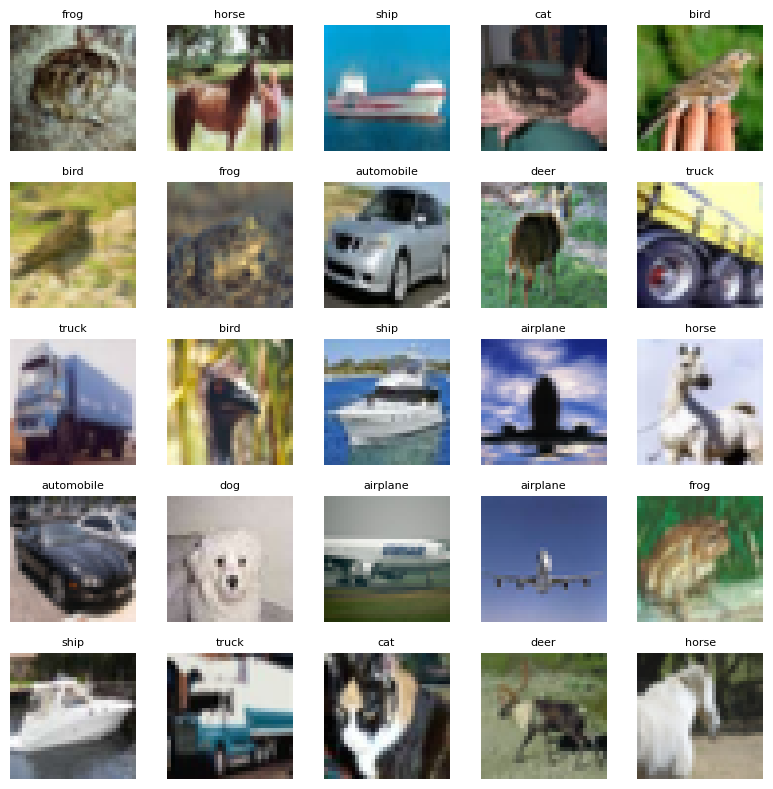

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

As imagens do CIFAR-10 apresentam certa complexidade para classificação, principalmente por possuírem baixa resolução, com apenas 32×32 pixels. Essa limitação reduz a quantidade de detalhes visuais disponíveis para o modelo, dificultando a distinção entre objetos semelhantes. Além disso, as imagens apresentam variações de posição, iluminação, ângulo e fundo, o que torna o problema mais desafiador. Algumas classes podem ser facilmente confundidas, como **gato e cachorro**, **automóvel e caminhão**, ou até **pássaro e avião**, pois possuem formas e características visuais parecidas quando observadas em baixa resolução.

### <font color='#2D9CDB'>Q4) Plote a distribuição das classes do conjunto de treinamento utilizando um gráfico de barras. Com base no gráfico obtido, analise se o dataset é balanceado ou desbalanceado, compare a quantidade de amostras entre as classes e discuta se o balanceamento das classes pode impactar o treinamento e o desempenho de uma rede neural.</font>

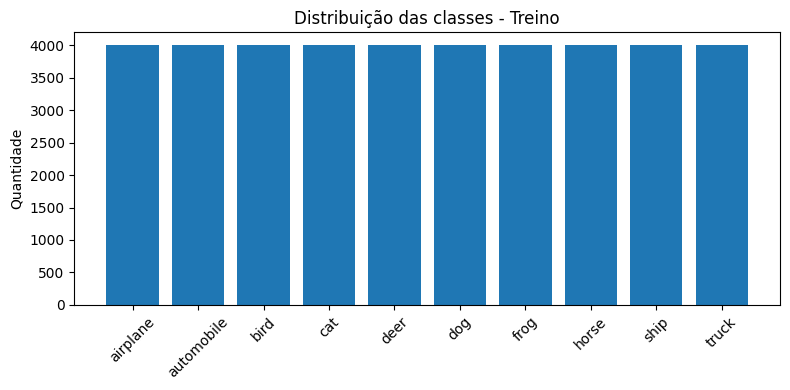

{'airplane': np.int64(4000), 'automobile': np.int64(4000), 'bird': np.int64(4000), 'cat': np.int64(4000), 'deer': np.int64(4000), 'dog': np.int64(4000), 'frog': np.int64(4000), 'horse': np.int64(4000), 'ship': np.int64(4000), 'truck': np.int64(4000)}


In [ ]:
counts = np.bincount(y_train)
plt.figure(figsize=(8, 4))
plt.bar(class_names, counts)
plt.title("Distribuição das classes - Treino")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(dict(zip(class_names, counts)))

O gráfico de distribuição das classes mostra que o conjunto de treinamento está **balanceado**, pois todas as classes possuem aproximadamente a mesma quantidade de imagens. Esse equilíbrio é importante porque evita que o modelo aprenda de forma tendenciosa para classes com maior número de amostras. Em datasets desbalanceados, a rede neural poderia apresentar bom desempenho apenas nas classes majoritárias e baixo desempenho nas classes menos representadas. Como o CIFAR-10 possui uma distribuição uniforme, todas as classes contribuem de maneira semelhante para o treinamento e para o cálculo da função de custo.

### <font color='#2D9CDB'>Q5) Verifique os valores mínimo e máximo dos pixels das imagens do conjunto de treinamento. Em seguida, normalize os conjuntos de treino, validação e teste dividindo os valores dos pixels por 255. Após a normalização, verifique novamente os valores mínimo e máximo e explique por que esse procedimento é importante para o treinamento de redes neurais profundas. Discuta também como a normalização influencia a estabilidade numérica do treinamento e a velocidade de convergência do algoritmo de otimização.</font>

In [ ]:
print(f"Antes: min={x_train.min()}, max={x_train.max()}")

x_train = x_train / 255.0
x_val   = x_val   / 255.0
x_test  = x_test  / 255.0

print(f"Depois: min={x_train.min():.4f}, max={x_train.max():.4f}")

Antes: min=0, max=255
Depois: min=0.0000, max=1.0000


A normalização transforma os valores dos pixels, originalmente no intervalo de 0 a 255, para uma escala entre 0 e 1. Esse procedimento é importante porque redes neurais treinam melhor quando as entradas estão em uma faixa numérica menor e mais estável. Com os dados normalizados, o processo de otimização tende a ser mais eficiente, reduzindo o risco de atualizações muito grandes nos pesos e melhorando a estabilidade dos gradientes. Além disso, a normalização geralmente acelera a convergência do modelo, pois torna os valores de entrada mais compatíveis com a escala utilizada na inicialização dos pesos da rede.

### <font color='#2D9CDB'>Q6) Explique por que as imagens do CIFAR-10 podem ser representadas como tensores tridimensionais. Em seguida, identifique o significado de cada dimensão do tensor (32, 32, 3), explique o papel dos canais RGB e discuta a diferença entre imagens coloridas e imagens em tons de cinza no contexto de redes neurais convolucionais.</font>

Cada imagem do CIFAR-10 pode ser representada como um tensor tridimensional no formato **(32, 32, 3)**. As duas primeiras dimensões representam a estrutura espacial da imagem, ou seja, sua altura e largura em pixels. A terceira dimensão representa os canais de cor RGB: vermelho, verde e azul. Cada canal armazena a intensidade de uma cor primária em cada pixel. Em imagens coloridas, a rede recebe informações espaciais e cromáticas; já em imagens em tons de cinza, existe apenas um canal, contendo a intensidade luminosa. Em redes convolucionais, essa diferença é importante porque os filtros operam sobre todos os canais da imagem, permitindo aprender padrões de forma, textura e cor.

# <font color='green'><u><b>Parte 2 - MLP</b></u></font>

### <font color='#2D9CDB'>Q7) As redes neurais do tipo Multilayer Perceptron (MLP) utilizam camadas densamente conectadas e, portanto, esperam vetores unidimensionais como entrada. Explique por que é necessário transformar as imagens do CIFAR-10 antes de utilizá-las em uma MLP e discuta o que acontece com a estrutura espacial das imagens durante esse processo. Em seguida, construa uma rede neural MLP utilizando a API Sequential do Keras com uma camada Flatten, duas camadas densas escondidas com função de ativação ReLU e uma camada de saída com 10 neurônios e ativação Softmax.</font>

In [ ]:
mlp = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


As redes MLP trabalham com entradas unidimensionais, por isso é necessário transformar cada imagem do formato **(32, 32, 3)** em um vetor com **3.072 valores**. Esse processo é conhecido como achatamento (*flattening*). Apesar de permitir que a imagem seja usada em uma MLP, essa transformação remove a organização espacial dos pixels. Assim, relações importantes de vizinhança, como bordas, contornos e texturas locais, deixam de ser representadas explicitamente. Como consequência, a MLP passa a tratar os pixels como variáveis independentes, o que limita sua capacidade de reconhecer padrões visuais complexos.

### <font color='#2D9CDB'>Q8) Exiba o resumo da arquitetura da rede neural criada utilizando o método summary() e analise a quantidade de parâmetros treináveis da MLP. Com base nas dimensões das imagens do CIFAR-10 e no número de neurônios utilizados nas camadas densas, discuta por que MLPs podem rapidamente se tornar modelos muito grandes para problemas de classificação de imagens.</font>

In [ ]:
mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

A função de custo mede o erro entre a saída prevista pela rede e a classe correta de cada imagem. Durante o treinamento, esse valor orienta o processo de ajuste dos pesos por meio do algoritmo de otimização. O otimizador Adam busca minimizar essa perda de forma adaptativa, ajustando os pesos da rede com base nos gradientes calculados. A combinação entre **Softmax** e **sparse categorical crossentropy** é adequada para classificação multiclasse porque o Softmax transforma as saídas em probabilidades distribuídas entre as 10 classes, enquanto a entropia cruzada penaliza previsões incorretas, principalmente quando o modelo atribui baixa probabilidade à classe verdadeira.

### <font color='#2D9CDB'>Q9) Compile a MLP utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, explique o papel da função de custo durante o treinamento, o objetivo do algoritmo de otimização e por que a combinação entre Softmax e entropia cruzada é adequada para problemas de classificação multiclasse.</font>

In [ ]:
mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

A função de custo mede o erro entre a saída prevista pela rede e a classe correta de cada imagem. Durante o treinamento, esse valor orienta o processo de ajuste dos pesos por meio do algoritmo de otimização. O otimizador Adam busca minimizar essa perda de forma adaptativa, ajustando os pesos da rede com base nos gradientes calculados. A combinação entre **Softmax** e **sparse categorical crossentropy** é adequada para classificação multiclasse porque o Softmax transforma as saídas em probabilidades distribuídas entre as 10 classes, enquanto a entropia cruzada penaliza previsões incorretas, principalmente quando o modelo atribui baixa probabilidade à classe verdadeira.

### <font color='#2D9CDB'>Q10) Treine a rede neural por 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History e, em seguida, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação. Após gerar os gráficos, analise o comportamento do treinamento, discutindo se o modelo aparenta convergir adequadamente, se há estabilidade durante o treinamento e se existem indícios de overfitting.</font>

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.3117 - loss: 1.9030 - val_accuracy: 0.3697 - val_loss: 1.7669
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3921 - loss: 1.6955 - val_accuracy: 0.4098 - val_loss: 1.6451
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4254 - loss: 1.6091 - val_accuracy: 0.4341 - val_loss: 1.5911
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.4451 - loss: 1.5464 - val_accuracy: 0.4363 - val_loss: 1.5879
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.4637 - loss: 1.5040 - val_accuracy: 0.4585 - val_loss: 1.5372
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.4782 - loss: 1.4637 - val_accuracy: 0.4653 - val_loss: 1.5138
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.4886 - loss: 1.4348 - val_accuracy: 0.4544 - val_loss: 1.5377
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.4978 - loss: 1.4075 - 

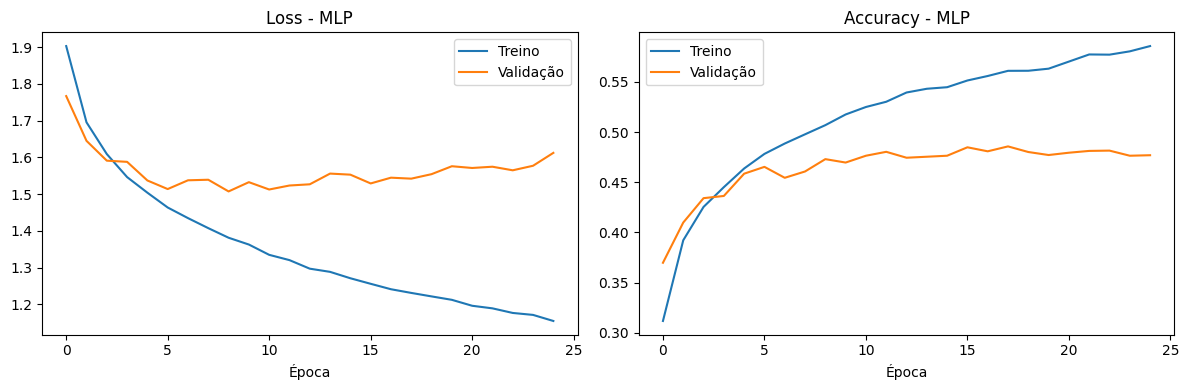

In [ ]:
history_mlp = mlp.fit(
    x_train, y_train,
    epochs=25,
    validation_data=(x_val, y_val),
    batch_size=64
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_mlp.history['loss'], label='Treino')
axes[0].plot(history_mlp.history['val_loss'], label='Validação')
axes[0].set_title('Loss - MLP')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history_mlp.history['accuracy'], label='Treino')
axes[1].plot(history_mlp.history['val_accuracy'], label='Validação')
axes[1].set_title('Accuracy - MLP')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()


Durante o treinamento da MLP, a perda no conjunto de treino tende a diminuir e a acurácia tende a aumentar, indicando que o modelo está aprendendo os padrões presentes nos dados de treinamento. No entanto, a acurácia de validação se estabiliza em um valor inferior à de treino, enquanto o desempenho no treino continua melhorando. Esse comportamento indica a presença de **overfitting**, pois o modelo passa a memorizar características específicas do conjunto de treino e não consegue generalizar com a mesma eficiência para dados novos. Essa limitação está relacionada ao uso de uma MLP em imagens, já que a arquitetura não preserva a estrutura espacial dos pixels.

### <font color='#2D9CDB'>Q11) Avalie o desempenho da MLP utilizando o conjunto de teste e reporte os valores de loss e accuracy obtidos. Em seguida, compare os resultados dos conjuntos de treinamento e teste e discuta se o modelo aparenta apresentar boa capacidade de generalização.</font>

In [ ]:
loss_test, acc_test = mlp.evaluate(x_test, y_test)
loss_train, acc_train = mlp.evaluate(x_train, y_train)
print(f"Treino  -> Loss: {loss_train:.4f} | Acc: {acc_train:.4f}")
print(f"Teste   -> Loss: {loss_test:.4f}  | Acc: {acc_test:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4744 - loss: 1.6115
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5519 - loss: 1.2757
Treino  -> Loss: 1.2757 | Acc: 0.5519
Teste   -> Loss: 1.6115  | Acc: 0.4744


A avaliação no conjunto de teste mostra que a MLP possui desempenho inferior ao observado no treinamento. Essa diferença entre os resultados de treino e teste indica que o modelo não apresenta boa capacidade de generalização. Apesar de conseguir aprender parte dos padrões do conjunto de treinamento, a MLP tem dificuldade em classificar corretamente imagens não vistas, principalmente porque não explora relações espaciais entre pixels. Assim, o desempenho obtido reforça a limitação dessa arquitetura para problemas de visão computacional mais complexos, como o CIFAR-10.

### <font color='#2D9CDB'>Q12) Utilize a MLP treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita pelo modelo e compare-a com a classe verdadeira da imagem. Com base nas probabilidades obtidas, explique o significado da saída Softmax e discuta se o modelo está realizando previsões com alta ou baixa confiança.</font>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


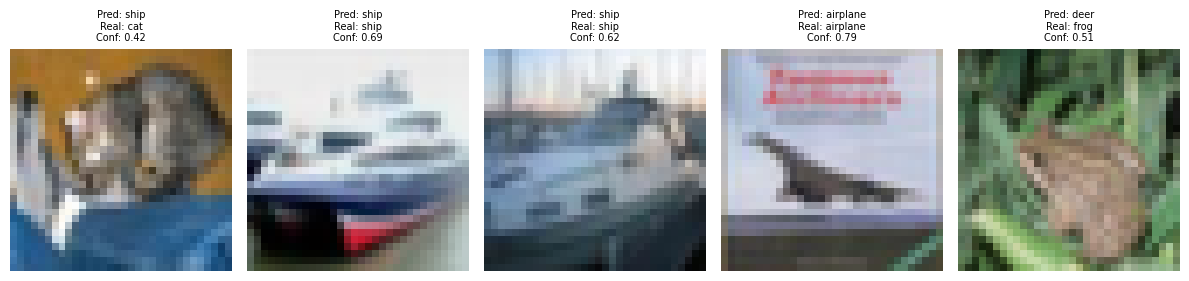

In [ ]:
n = 5
preds = mlp.predict(x_test[:n])

fig, axes = plt.subplots(1, n, figsize=(12, 3))
for i in range(n):
    ax = axes[i]
    ax.imshow(x_test[i])
    pred_class = np.argmax(preds[i])
    conf = preds[i][pred_class]
    ax.set_title(f"Pred: {class_names[pred_class]}\nReal: {class_names[y_test[i]]}\nConf: {conf:.2f}", fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()


A saída da camada Softmax representa uma distribuição de probabilidade entre as 10 classes do CIFAR-10. A classe com maior probabilidade é escolhida como a previsão final do modelo. Quando uma probabilidade se destaca muito em relação às demais, isso indica maior confiança da rede naquela classificação. Por outro lado, quando as probabilidades ficam distribuídas de forma mais equilibrada entre várias classes, o modelo demonstra incerteza. No caso da MLP, é comum observar previsões com confiança moderada, pois a rede não preserva a estrutura espacial da imagem e, por isso, tem mais dificuldade em identificar características visuais discriminativas.

### <font color='#2D9CDB'>Q13) Plote a matriz de confusão da MLP utilizando o conjunto de teste. Em seguida, identifique quais classes foram mais confundidas pelo modelo e discuta possíveis razões para esses erros de classificação, considerando as limitações de uma arquitetura MLP aplicada a problemas de visão computacional.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


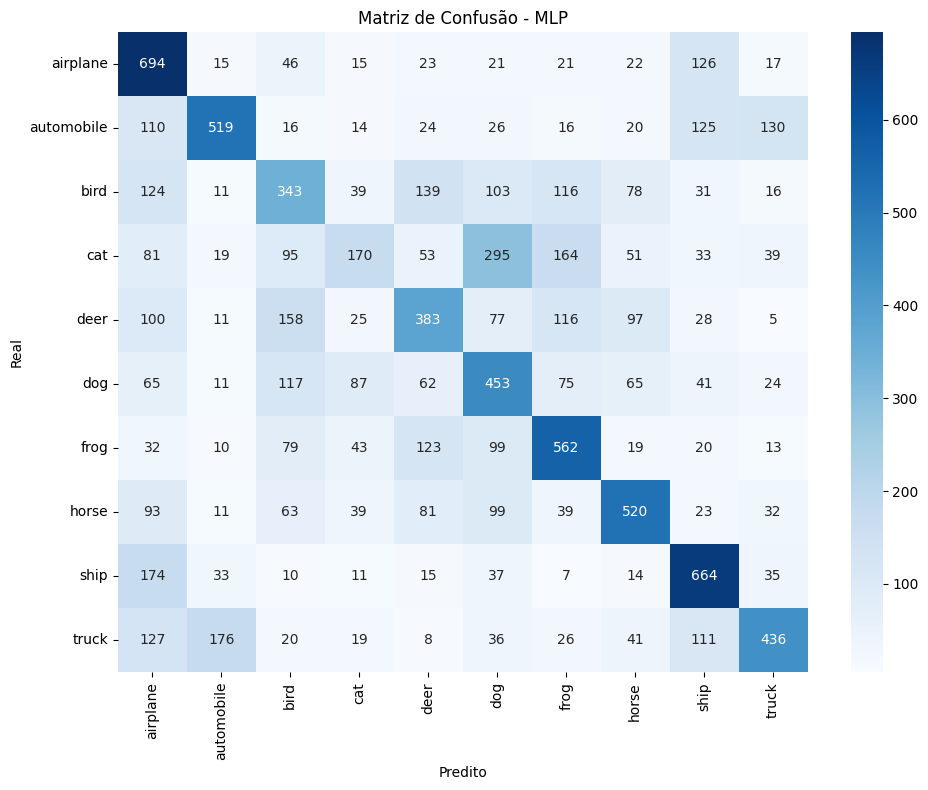

In [ ]:
y_pred_mlp = np.argmax(mlp.predict(x_test), axis=1)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusão - MLP")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.tight_layout()
plt.show()


A matriz de confusão da MLP mostra que os principais erros ocorrem entre classes visualmente semelhantes, como **gato e cachorro**, **automóvel e caminhão** e, em alguns casos, **pássaro e avião**. Essas confusões são esperadas porque as imagens têm baixa resolução e algumas classes compartilham formas, texturas e cores parecidas. Como a MLP transforma a imagem em um vetor, ela perde informações espaciais importantes, como bordas, contornos e relações locais entre pixels. Essa limitação dificulta o aprendizado de padrões visuais robustos, aumentando os erros em classes com características semelhantes.

### <font color='#2D9CDB'>Q14) Com base nos resultados obtidos ao longo desta etapa, discuta as principais vantagens e limitações das redes MLP para classificação de imagens. Em sua resposta, considere aspectos como preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização e desempenho obtido no CIFAR-10.</font>

As redes MLP apresentam como principal vantagem a simplicidade de implementação e compreensão. Elas podem funcionar bem em problemas com dados tabulares ou imagens muito simples. No entanto, para classificação de imagens, apresentam limitações importantes. A primeira é a perda da estrutura espacial causada pelo achatamento da imagem. A segunda é o grande número de parâmetros gerado pelas camadas densas, o que aumenta o custo computacional e o risco de overfitting. No CIFAR-10, o desempenho da MLP fica limitado, mostrando que essa arquitetura não é a mais adequada para problemas de visão computacional.

# <font color='green'><u><b>Parte 3 - CNN</b></u></font>

### <font color='#2D9CDB'>Q15) As redes neurais convolucionais (CNNs) foram desenvolvidas para lidar melhor com dados que possuem estrutura espacial, como imagens. Explique por que arquiteturas MLP apresentam limitações em problemas de visão computacional e descreva como as CNNs conseguem preservar relações espaciais entre os pixels. Em seguida, explique os conceitos de convolução, filtros convolucionais e mapas de características (feature maps).</font>

MLPs ignoram a topologia espacial da imagem ao vetorizar a entrada, impossibilitando o aprendizado de padrões locais. CNNs preservam a grade espacial e aplicam filtros convolucionais — matrizes de pesos deslizantes que detectam padrões locais (bordas, texturas, formas) em qualquer posição da imagem (**compartilhamento de pesos**). Cada filtro gera um feature map, que representa a intensidade de ativação de um padrão específico ao longo da imagem. Camadas sucessivas combinam esses mapas para aprender representações hierárquicas cada vez mais abstratas.

### <font color='#2D9CDB'>Q16) Construa uma rede neural convolucional utilizando a API Sequential do Keras. A arquitetura da CNN deve conter camadas Conv2D com ativação ReLU, camadas MaxPooling2D, uma camada Flatten e uma camada de saída com 10 neurônios e ativação Softmax. Após construir a arquitetura, explique o papel das camadas convolucionais, das camadas de pooling e da camada Flatten dentro da CNN.</font>

In [ ]:
cnn = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


As camadas **Conv2D** são responsáveis por aplicar filtros convolucionais sobre as imagens, extraindo padrões locais como bordas, texturas e formas. As camadas **MaxPooling2D** reduzem a dimensão espacial dos mapas de características, mantendo as informações mais relevantes e diminuindo o custo computacional. Além disso, o pooling ajuda a tornar o modelo menos sensível a pequenas variações de posição dos objetos. Por fim, a camada **Flatten** transforma os mapas de características em um vetor unidimensional, permitindo que as camadas densas finais realizem a classificação entre as 10 classes.

### <font color='#2D9CDB'>Q17) Exiba o resumo da arquitetura da CNN utilizando o método summary() e compare a quantidade de parâmetros treináveis da CNN com a da MLP construída anteriormente. Em seguida, discuta por que CNNs costumam ser mais eficientes para classificação de imagens, mesmo utilizando menos parâmetros treináveis.</font>

In [ ]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,226 (8.37 MB)

 Trainable params: 2,193,226 (8.37 MB)

 Non-trainable params: 0 (0.00 B)

A CNN possui uma quantidade de parâmetros treináveis menor que a MLP, mesmo sendo mais adequada para imagens. Isso ocorre porque os filtros convolucionais são compartilhados ao longo da imagem, ou seja, o mesmo conjunto de pesos é aplicado em diferentes regiões. Por exemplo, um filtro 3×3 precisa aprender poucos pesos, independentemente do tamanho total da imagem. Na MLP, por outro lado, cada pixel é conectado individualmente aos neurônios das camadas densas. Essa eficiência paramétrica, somada à preservação da estrutura espacial, permite que CNNs aprendam padrões visuais de forma mais eficiente e generalizem melhor.

### <font color='#2D9CDB'>Q18) Compile a CNN utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, treine o modelo por até 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History. Após o treinamento, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação e analise o comportamento do treinamento da CNN.</font>

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 163ms/step - accuracy: 0.4521 - loss: 1.4982 - val_accuracy: 0.5908 - val_loss: 1.1595
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 160ms/step - accuracy: 0.6231 - loss: 1.0687 - val_accuracy: 0.6605 - val_loss: 0.9780
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 165ms/step - accuracy: 0.6930 - loss: 0.8758 - val_accuracy: 0.6889 - val_loss: 0.9020
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 176ms/step - accuracy: 0.7433 - loss: 0.7322 - val_accuracy: 0.7024 - val_loss: 0.8698
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 136s 165ms/step - accuracy: 0.7807 - loss: 0.6259 - val_accuracy: 0.6913 - val_loss: 0.9269
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 175ms/step - accuracy: 0.8151 - loss: 0.5275 - val_accuracy: 0.6712 - val_loss: 1.0410
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 172ms/step - accuracy: 0.8457 - loss: 0.4382 - val_accuracy: 0.6973 - val_loss: 1.0086
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 172ms/step - accuracy: 0.8731 -

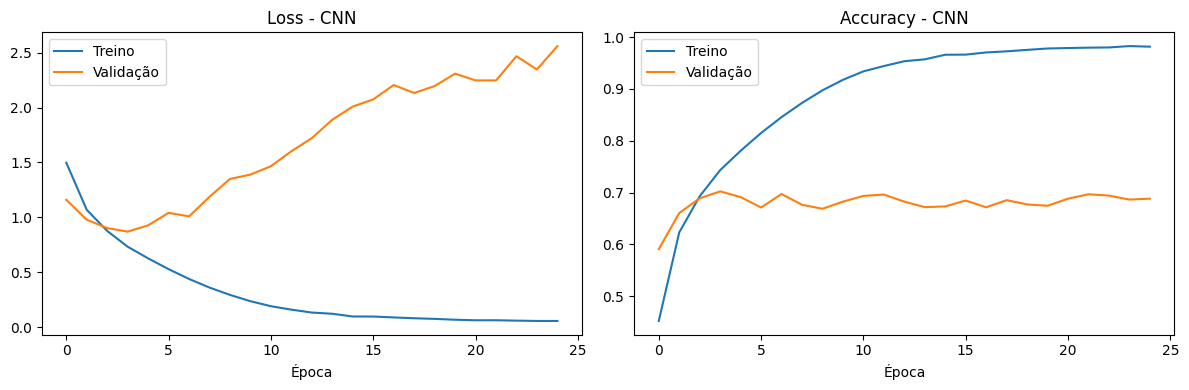

In [ ]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn.fit(
    x_train, y_train,
    epochs=25,
    validation_data=(x_val, y_val),
    batch_size=64
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_cnn.history['loss'], label='Treino')
axes[0].plot(history_cnn.history['val_loss'], label='Validação')
axes[0].set_title('Loss - CNN')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history_cnn.history['accuracy'], label='Treino')
axes[1].plot(history_cnn.history['val_accuracy'], label='Validação')
axes[1].set_title('Accuracy - CNN')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

O treinamento da CNN apresenta comportamento mais estável e desempenho superior ao da MLP. A acurácia de validação atinge valores mais altos, indicando que a rede consegue aprender padrões visuais mais úteis para a classificação. Embora ainda possa existir algum overfitting nas últimas épocas, a diferença entre treino e validação tende a ser menor do que na MLP. Isso ocorre porque a CNN preserva a estrutura espacial das imagens e aprende características locais por meio dos filtros convolucionais, o que favorece uma melhor capacidade de generalização.

### <font color='#2D9CDB'>Q19) Avalie o desempenho da CNN utilizando o conjunto de teste e compare os resultados obtidos com aqueles alcançados pela MLP. Em seguida, discuta as diferenças observadas em termos de accuracy, capacidade de generalização e aprendizado de características visuais.</font>

In [ ]:
loss_cnn, acc_cnn = cnn.evaluate(x_test, y_test)
print(f"CNN  -> Loss: {loss_cnn:.4f} | Acc: {acc_cnn:.4f}")
print(f"MLP  -> Loss: {loss_test:.4f} | Acc: {acc_test:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6899 - loss: 2.5712
CNN  -> Loss: 2.5712 | Acc: 0.6899
MLP  -> Loss: 1.6115 | Acc: 0.4744


A CNN apresenta desempenho superior ao da MLP no conjunto de teste. A principal razão para essa melhora é que a CNN consegue explorar a estrutura espacial das imagens, aprendendo padrões locais como bordas, texturas e formas. Esses padrões são combinados progressivamente em camadas mais profundas, formando representações visuais mais abstratas e úteis para a classificação. Enquanto a MLP trata os pixels como variáveis independentes, a CNN considera a organização espacial da imagem, o que melhora a discriminação entre classes visualmente parecidas e aumenta a capacidade de generalização.

### <font color='#2D9CDB'>Q20) Utilize a CNN treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita e compare-a com a classe verdadeira da imagem. Em seguida, analise se a CNN aparenta realizar previsões mais confiantes que a MLP e discuta possíveis razões para esse comportamento.</font>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


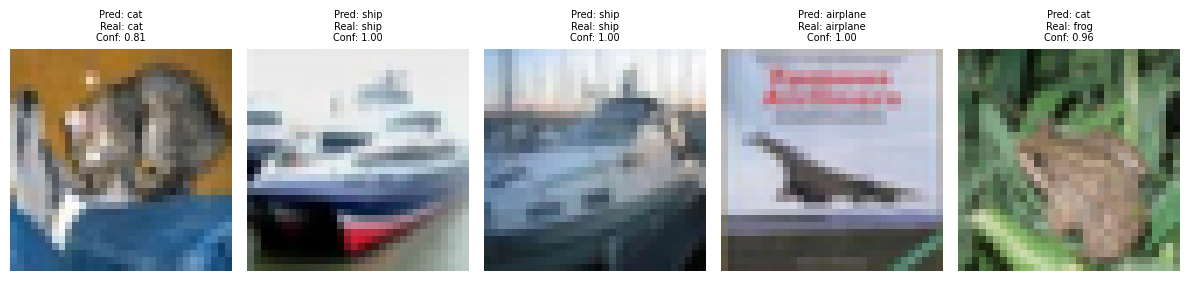

In [ ]:
n = 5
preds_cnn = cnn.predict(x_test[:n])

fig, axes = plt.subplots(1, n, figsize=(12, 3))
for i in range(n):
    ax = axes[i]
    ax.imshow(x_test[i])
    pred_class = np.argmax(preds_cnn[i])
    conf = preds_cnn[i][pred_class]
    ax.set_title(f"Pred: {class_names[pred_class]}\nReal: {class_names[y_test[i]]}\nConf: {conf:.2f}", fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()


As previsões da CNN tendem a ser mais confiantes do que as previsões da MLP. Isso ocorre porque a CNN aprende representações visuais mais coerentes com a estrutura das imagens, capturando padrões locais e hierárquicos. Quando a rede identifica características bem definidas de uma classe, a saída Softmax concentra maior probabilidade nessa classe. Assim, valores mais altos de probabilidade indicam maior confiança na previsão. Mesmo assim, em imagens ambíguas ou de baixa resolução, a CNN ainda pode apresentar incerteza, especialmente entre classes com aparência semelhante.

### <font color='#2D9CDB'>Q21) Plote a matriz de confusão da CNN utilizando o conjunto de teste e compare-a com a matriz de confusão obtida pela MLP. Identifique quais classes apresentaram melhora significativa de classificação e discuta por que CNNs conseguem reduzir confusões entre classes visualmente semelhantes.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


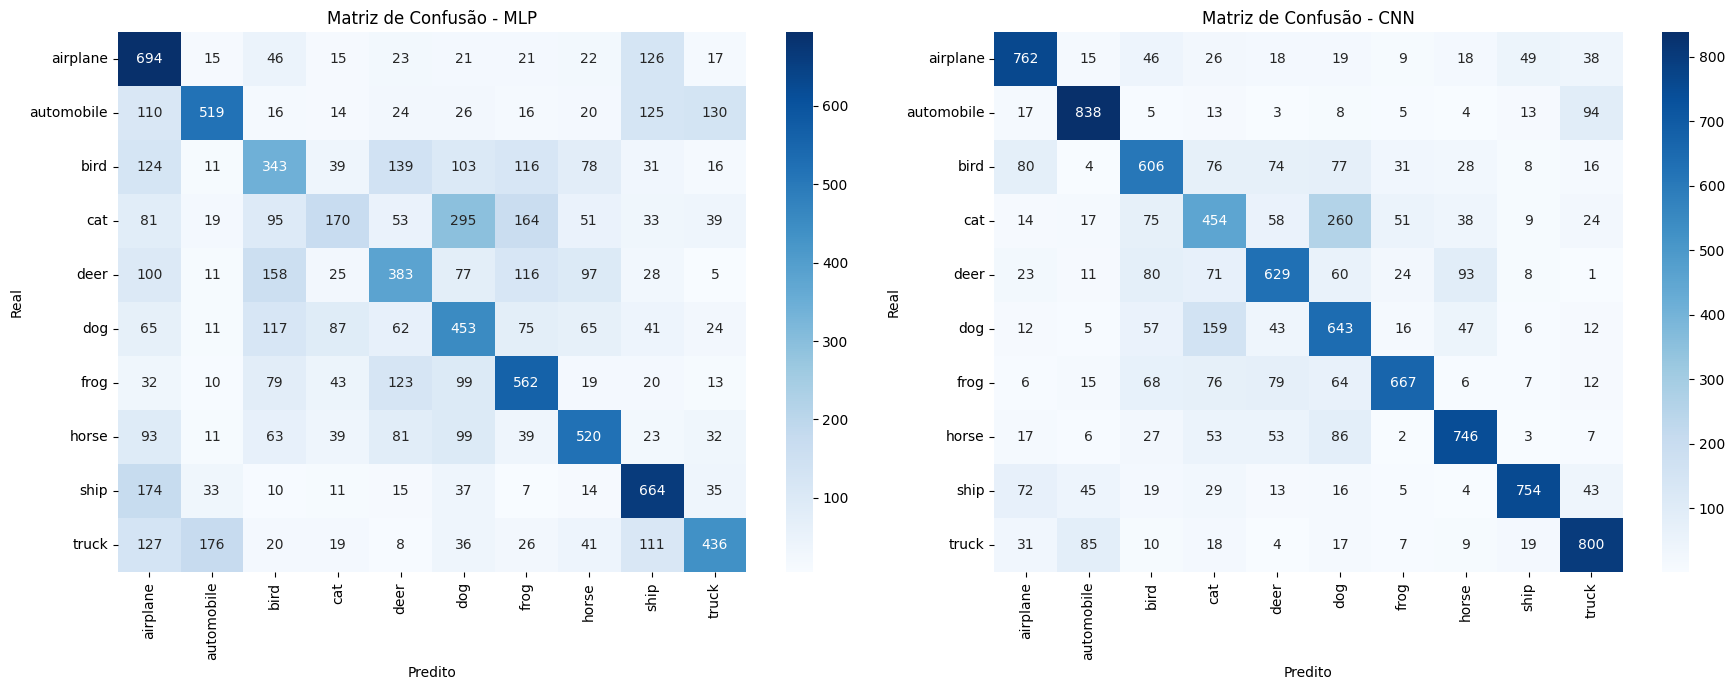

In [ ]:
y_pred_cnn = np.argmax(cnn.predict(x_test), axis=1)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, cm, title in zip(axes, [cm_mlp, cm_cnn], ['MLP', 'CNN']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"Matriz de Confusão - {title}")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predito")
plt.tight_layout()
plt.show()


A matriz de confusão da CNN mostra uma redução nos erros em relação à MLP, principalmente em classes que dependem de padrões visuais locais para serem diferenciadas. A melhora ocorre porque os filtros convolucionais aprendem características como contornos, texturas e partes dos objetos, o que ajuda a separar classes visualmente semelhantes. Ainda podem ocorrer confusões entre pares como **gato e cachorro** ou **automóvel e caminhão**, mas em menor intensidade. De forma geral, a CNN apresenta maior capacidade de distinguir as classes porque utiliza melhor a informação espacial presente nas imagens.

### <font color='#2D9CDB'>Q22) Adicione camadas Dropout à CNN e treine novamente o modelo. Em seguida, plote as curvas de loss e accuracy para os conjuntos de treinamento e validação e compare os resultados com a CNN original. Com base nos gráficos obtidos, discuta o impacto do Dropout no overfitting e na capacidade de generalização da rede neural.</font>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 177ms/step - accuracy: 0.3874 - loss: 1.6560 - val_accuracy: 0.5387 - val_loss: 1.2865
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 171ms/step - accuracy: 0.5379 - loss: 1.2931 - val_accuracy: 0.6344 - val_loss: 1.0431
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 170ms/step - accuracy: 0.6068 - loss: 1.1186 - val_accuracy: 0.6750 - val_loss: 0.9319
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 170ms/step - accuracy: 0.6443 - loss: 1.0151 - val_accuracy: 0.6957 - val_loss: 0.8751
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 168ms/step - accuracy: 0.6740 - loss: 0.9289 - val_accuracy: 0.7065 - val_loss: 0.8423
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 167ms/step - accuracy: 0.6977 - loss: 0.8631 - val_accuracy: 0.7139 - val_loss: 0.8262
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 171ms/step - accuracy: 0.7195 - loss: 0.8066 - val_accuracy: 0.7261 - val_loss: 0.7820
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 173ms/step - accuracy: 0.7338 -

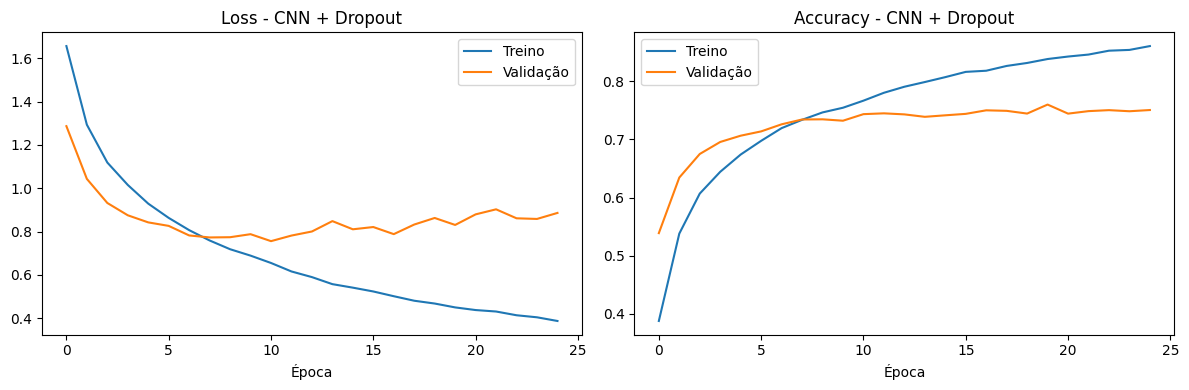

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7477 - loss: 0.9055
CNN + Dropout -> Loss: 0.9055 | Acc: 0.7477
CNN original  -> Loss: 2.5712 | Acc: 0.6899


In [ ]:
cnn_drop = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

cnn_drop.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_drop = cnn_drop.fit(
    x_train, y_train,
    epochs=25,
    validation_data=(x_val, y_val),
    batch_size=64
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_drop.history['loss'], label='Treino')
axes[0].plot(history_drop.history['val_loss'], label='Validação')
axes[0].set_title('Loss - CNN + Dropout')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history_drop.history['accuracy'], label='Treino')
axes[1].plot(history_drop.history['val_accuracy'], label='Validação')
axes[1].set_title('Accuracy - CNN + Dropout')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

loss_drop, acc_drop = cnn_drop.evaluate(x_test, y_test)
print(f"CNN + Dropout -> Loss: {loss_drop:.4f} | Acc: {acc_drop:.4f}")
print(f"CNN original  -> Loss: {loss_cnn:.4f} | Acc: {acc_cnn:.4f}")


O Dropout atua como uma técnica de regularização, desativando aleatoriamente parte dos neurônios durante o treinamento. Isso impede que a rede dependa excessivamente de combinações específicas de neurônios e força o modelo a aprender representações mais robustas. Com o uso de Dropout, a acurácia de treinamento pode ficar menor em comparação à CNN original, mas a diferença entre treino e validação tende a diminuir. Esse comportamento indica redução do overfitting e melhora na capacidade de generalização, pois o modelo passa a se adaptar melhor a imagens não vistas.

### <font color='#2D9CDB'>Q23) Com base em todos os resultados obtidos ao longo da atividade, compare as arquiteturas MLP e CNN para classificação de imagens. Em sua resposta, discuta diferenças relacionadas à preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização, desempenho obtido no CIFAR-10 e adequação de cada arquitetura para problemas de visão computacional.</font>

A comparação entre MLP e CNN mostra que a principal diferença está na forma como cada arquitetura trata a estrutura das imagens. A MLP achata a imagem em um vetor, eliminando a relação de vizinhança entre pixels. Já a CNN preserva essa estrutura e utiliza convoluções para aprender padrões locais, como bordas, texturas e formas. Essa característica torna a CNN muito mais adequada para visão computacional.

Além disso, a MLP tende a possuir muitos parâmetros treináveis, principalmente nas primeiras camadas densas, o que aumenta o risco de overfitting. A CNN, por usar compartilhamento de pesos nos filtros convolucionais, consegue ser mais eficiente e aprender representações visuais melhores com menos parâmetros. Nos resultados obtidos com o CIFAR-10, a CNN apresentou melhor desempenho e maior capacidade de generalização, especialmente quando combinada com técnicas de regularização como Dropout. Portanto, para classificação de imagens, CNNs são mais apropriadas do que MLPs.